In [1]:
# A1) Import libraries
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from math import ceil
from scipy.stats import norm
import pandas as pd

In [2]:
# A2) Reproducibility
np.random.seed(42)

# A3) Sample size (khas studi lab)
n = 20

# A4) SUS ~ N(73, 19^2) dipotong 0..100 (borderline di atas 67)
sus_mean_true = 73
sus_sd_true = 19
sus_scores = np.clip(np.random.normal(sus_mean_true, sus_sd_true, n), 0, 100)

# A5) Success ~ Binomial(p=0.78) (mendekati target 0.80)
p_success_true = 0.78
task_success = np.random.binomial(1, p_success_true, size=n)

# A6) DataFrame ringkas
df = pd.DataFrame({
    "sus_score": sus_scores,
    "task_success": task_success
})

print(df.head())
print("N =", len(df))
print("Mean SUS =", round(df['sus_score'].mean(), 2))
print("p̂ success =", round(df['task_success'].mean(), 3))

    sus_score  task_success
0   82.437569             1
1   70.372978             0
2   85.306082             1
3  100.000000             1
4   68.551086             1
N = 20
Mean SUS = 69.5
p̂ success = 0.75


## B. Fungsi Uji: t-test (one-sided), exact & mid-p, z-test (jika layak)

### 1) Uji SUS > 67 (one-sample t-test + CI 90%)

In [3]:
# B1) One-sample t-test (one-sided) untuk SUS > 67
benchmark_sus = 67.0

xbar = df['sus_score'].mean()
s = df['sus_score'].std(ddof=1)
n = df.shape[0]
t_stat = (xbar - benchmark_sus) / (s / np.sqrt(n))

# p-value dua sisi dari scipy, lalu konversi ke satu sisi
t_two = stats.ttest_1samp(df['sus_score'], popmean=benchmark_sus, alternative='two-sided')
p_one_sided_t = t_two.pvalue/2 if t_stat > 0 else 1 - t_two.pvalue/2

# CI dua sisi 90% (trik uji satu sisi α=0.05)
alpha = 0.10
t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
ci_low = xbar - t_crit * s/np.sqrt(n)
ci_high = xbar + t_crit * s/np.sqrt(n)

print("\n=== One-sample t-test (SUS > 67) ===")
print("t =", round(t_stat, 3), "| df =", n-1, "| p(one-sided) =", round(p_one_sided_t, 4))
print("CI90% mean SUS: [", round(ci_low,2), ",", round(ci_high,2), "]")


=== One-sample t-test (SUS > 67) ===
t = 0.628 | df = 19 | p(one-sided) = 0.2687
CI90% mean SUS: [ 62.62 , 76.37 ]


### 2) Uji proporsi success ≥ 0.80 (exact & mid-p; z-test jika syarat terpenuhi)

In [4]:
# B2) One-sample proportion test (exact + mid-p), opsi z-test
p0 = 0.80
x_success = int(df['task_success'].sum())
p_hat = x_success / n

# Exact p(one-sided): P(X >= x_obs | n, p0)
p_exact = stats.binom.sf(x_success - 1, n, p0)

# mid-p(one-sided): P(X > x_obs) + 0.5*P(X = x_obs)
pmf_obs = stats.binom.pmf(x_success, n, p0)
p_mid = stats.binom.sf(x_success, n, p0) + 0.5*pmf_obs

print("\n=== One-sample proportion (success ≥ 0.80) ===")
print(f"n={n}, x={x_success}, p̂={p_hat:.3f}")
print("Exact p(one-sided) =", round(p_exact, 4))
print("Mid-p(one-sided)  =", round(p_mid, 4))

# z-test hanya bila syarat besar terpenuhi: n*p0 >= 15 dan n*(1-p0) >= 15 (konservatif)
if (n*p0 >= 15) and (n*(1-p0) >= 15):
    z = (p_hat - p0) / np.sqrt(p0*(1-p0)/n)
    p_one_sided_z = 1 - stats.norm.cdf(z)  # arah "lebih besar dari"
    print("z =", round(z, 3), "| p(one-sided) =", round(p_one_sided_z, 4))
else:
    print("z-test tidak direkomendasikan (n kecil relatif ke p0).")


=== One-sample proportion (success ≥ 0.80) ===
n=20, x=15, p̂=0.750
Exact p(one-sided) = 0.8042
Mid-p(one-sided)  = 0.7169
z-test tidak direkomendasikan (n kecil relatif ke p0).


## C. Visual: Histogram SUS + Benchmark + CI 90%

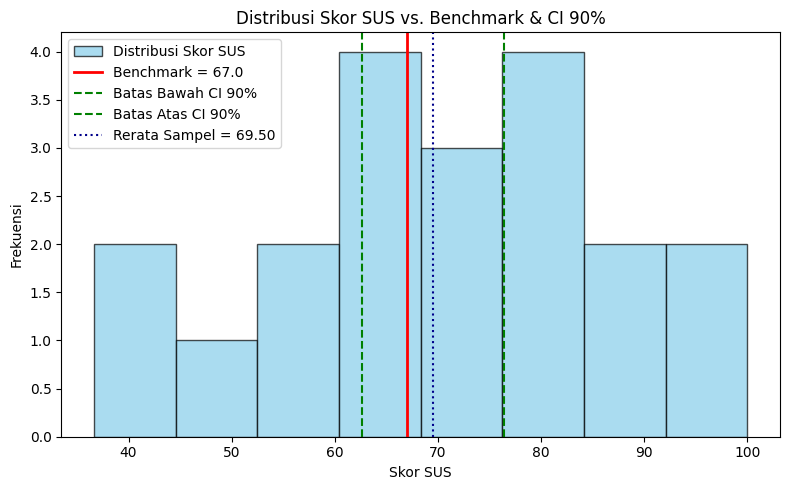

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(df['sus_score'], bins=8, color='skyblue', edgecolor='black', alpha=0.7, label='Distribusi Skor SUS')
plt.axvline(benchmark_sus, color='red', linestyle='-', linewidth=2, label=f'Benchmark = {benchmark_sus}')
plt.axvline(ci_low, color='green', linestyle="--", label='Batas Bawah CI 90%')
plt.axvline(ci_high, color='green', linestyle="--", label='Batas Atas CI 90%')
plt.axvline(xbar, color='darkblue', linestyle=':', label=f'Rerata Sampel = {xbar:.2f}')
plt.title("Distribusi Skor SUS vs. Benchmark & CI 90%")
plt.xlabel("Skor SUS")
plt.ylabel("Frekuensi")
plt.legend()
plt.tight_layout()
plt.show()

## D. Efek Ukuran (Cohen’s d) & Diagnostik Asumsi

In [6]:
# Cohen's d (one-sample): d = (xbar - mu0)/s
cohens_d = (xbar - benchmark_sus) / s
print("\nCohen's d (one-sample) =", round(cohens_d, 3))

# Normalitas (untuk SUS): Shapiro–Wilk
w, p_sw = stats.shapiro(df['sus_score'])
print("Shapiro–Wilk W =", round(w,3), "| p =", round(p_sw,4))
# Catatan: p > 0.05 → tidak ada bukti kuat untuk menolak asumsi normalitas. Jika p << 0.05, pertimbangkan transformasi log atau pendekatan non-parametrik.


Cohen's d (one-sample) = 0.14
Shapiro–Wilk W = 0.973 | p = 0.8096


## E. Perencanaan Ukuran Sampel Sederhana

In [7]:
# Target: pada uji mean satu sisi, ingin mendeteksi delta = (mu_target - mu0) dengan power tertentu.
from math import ceil
from scipy.stats import norm

alpha_one_sided = 0.05
power_target = 0.80

z_alpha = norm.ppf(1 - alpha_one_sided)   # ~1.645
z_beta  = norm.ppf(power_target)         # ~0.842

# Asumsi sd ~ 19 (dari historis), ingin mendeteksi selisih 6 poin (73 vs 67)
sd_assumed = 19.0
delta = 6.0

n_req = ((z_alpha + z_beta) * sd_assumed / delta)**2
print("\nPerkiraan N minimum (aproksimasi normal) =", ceil(n_req))


Perkiraan N minimum (aproksimasi normal) = 62


## F. Output Tabel Keputusan (ringkas)

In [10]:
decision = {
    "SUS_mean": round(xbar,2),
    "SUS_CI90_low": round(ci_low,2),
    "SUS_CI90_high": round(ci_high,2),
    "SUS_p_one_sided": round(p_one_sided_t,4),
    "Cohens_d": round(cohens_d,3),
    "Shapiro_p": round(p_sw,4),
    "Success_p_hat": round(p_hat,3),
    "Success_exact_p": round(p_exact,4),
    "Success_mid_p": round(p_mid,4),
    "Benchmark_SUS": benchmark_sus,
    "Benchmark_success": p0
}

pd.DataFrame([decision])

,SUS_mean,SUS_CI90_low,SUS_CI90_high,SUS_p_one_sided,Cohens_d,Shapiro_p,Success_p_hat,Success_exact_p,Success_mid_p,Benchmark_SUS,Benchmark_success
0,69.5,62.62,76.37,0.2687,0.14,0.8096,0.75,0.8042,0.7169,67.0,0.8


### Analisis System Usability Scale (SUS)

Klaim bahwa skor SUS ">67" **tidak kuat** karena kedua syarat utama tidak terpenuhi:

- **P-value > 0.05**: Nilai `p(one-sided)` adalah **0.2687**, yang jauh lebih besar dari 0.05. Ini menunjukkan tidak ada cukup bukti statistik untuk mendukung klaim tersebut.
    
- **CI Bawah < 67**: Batas bawah `CI90%` adalah **62.62**, yang berada di bawah ambang batas 67. Ini berarti kita tidak bisa 90% yakin bahwa skor SUS yang sebenarnya di populasi ada di atas 67.
    
- **Bonus (Cohen's d)**: Nilai `d` adalah **0.14**, yang menandakan ukuran efek yang sangat kecil (jauh di bawah 0.5).
    

---

### Analisis Tingkat Keberhasilan (_Success_)

Metrik _Success_ **tidak tercapai**.

- Penentu utamanya, `mid-p`, memiliki nilai **0.7169**, yang jauh lebih tinggi dari ambang batas 0.05.


## Landasan Teori & Rumus

<div class="single-code" style="width: 100%; font: inherit; background-color: #f9f9f9; border:1px solid #ccc; color: #333; padding: 10px; border-radius: 5px; margin-bottom:20px; word-wrap: break-word; overflow-wrap: break-word; max-height: 200px; overflow-y: auto;"><p>$$ t = \frac{\bar{x} - \mu_0}{s/\sqrt{n}} $$ </p></div> <div class="single-code" style="width: 100%; font: inherit; background-color: #f9f9f9; border:1px solid #ccc; color: #333; padding: 10px; border-radius: 5px; margin-bottom:20px; word-wrap: break-word; overflow-wrap: break-word; max-height: 200px; overflow-y: auto;"><p>$$ P(X=x)=\binom{n}{x}p_0^{x}(1-p_0)^{n-x} $$ </p></div> <div class="single-code" style="width: 100%; font: inherit; background-color: #f9f9f9; border:1px solid #ccc; color: #333; padding: 10px; border-radius: 5px; margin-bottom:20px; word-wrap: break-word; overflow-wrap: break-word; max-height: 200px; overflow-y: auto;"><p>$$ z = \frac{\hat{p}-p_0}{\sqrt{\frac{p_0(1-p_0)}{n}}} $$ </p></div> <div class="single-code" style="width: 100%; font: inherit; background-color: #f9f9f9; border:1px solid #ccc; color: #333; padding: 10px; border-radius: 5px; margin-bottom:20px; word-wrap: break-word; overflow-wrap: break-word; max-height: 200px; overflow-y: auto;"><p>$$ \text{mid-}p ;=; P(X > x_{\text{obs}}) ;+; \tfrac{1}{2}P(X = x_{\text{obs}}) $$ </p></div>

